# **Processed Data Load Karo**

In [1]:
import pandas as pd

df = pd.read_csv("/content/processed_temperature_data.csv")
df.head()

,timestamp,value,rolling_avg_24h,rolling_std_24h,lag_1h,diff_1h
0,2013-07-04 23:00:00,70.649957,70.470846,1.012776,72.187695,-1.537738
1,2013-07-05 00:00:00,71.342742,70.531759,1.019686,70.649957,0.692785
2,2013-07-05 01:00:00,71.586728,70.547030,1.033101,71.342742,0.243986
3,2013-07-05 02:00:00,70.977001,70.551163,1.034679,71.586728,-0.609727
4,2013-07-05 03:00:00,70.243882,70.604683,0.980569,70.977001,-0.733119


In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# **Isolation Forest Import + Setup**

In [3]:
from sklearn.ensemble import IsolationForest

features = ['value', 'rolling_avg_24h', 'rolling_std_24h', 'lag_1h', 'diff_1h']
X = df[features]

# **Model Initialization and Training**

In [4]:
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X)

IsolationForest(contamination=0.05, random_state=42)

# **Generate Anomaly Predictions**

In [5]:
df['anomaly'] = model.predict(X)
df['anomaly'].value_counts()

,count
anomaly,
1,6881
-1,363


# **Validate Detected Anomalies Against Known Events**

In [6]:
anomalies = df[df['anomaly'] == -1]
anomalies[['timestamp', 'value']].sort_values('timestamp').head(20)

,timestamp,value
76,2013-07-08 03:00:00,61.705110
78,2013-07-08 05:00:00,61.364476
91,2013-07-08 18:00:00,72.338302
92,2013-07-08 19:00:00,71.190825
95,2013-07-08 22:00:00,68.885723
758,2013-08-06 21:00:00,74.762234
891,2013-08-12 10:00:00,66.957848
1226,2013-08-26 09:00:00,64.621945
3154,2013-11-30 04:00:00,77.020015
3513,2013-12-15 03:00:00,76.680947


# **Inspect a Borderline Anomaly Case**

In [7]:
df[(df['timestamp'] >= '2013-07-08 00:00:00') & (df['timestamp'] <= '2013-07-08 10:00:00')][['timestamp', 'value', 'diff_1h', 'rolling_std_24h', 'anomaly']]

,timestamp,value,diff_1h,rolling_std_24h,anomaly
73,2013-07-08 00:00:00,62.480785,-1.765848,1.093806,1
74,2013-07-08 01:00:00,62.030554,-0.450231,1.164627,1
75,2013-07-08 02:00:00,63.411560,1.381006,1.163269,1
76,2013-07-08 03:00:00,61.705110,-1.706451,1.251836,-1
77,2013-07-08 04:00:00,62.775139,1.070030,1.151750,1
78,2013-07-08 05:00:00,61.364476,-1.410663,1.258463,-1
79,2013-07-08 06:00:00,61.689841,0.325365,1.322277,1
80,2013-07-08 07:00:00,62.200489,0.510648,1.253208,1
81,2013-07-08 08:00:00,62.982807,0.782318,1.135122,1
82,2013-07-08 09:00:00,64.448131,1.465324,1.108802,1


# **Confirm Full Coverage of the Major Anomaly Window**

In [8]:
df[(df['timestamp'] >= '2013-12-20') & (df['timestamp'] <= '2013-12-26')][['timestamp', 'value', 'anomaly']]

,timestamp,value,anomaly
3630,2013-12-20 00:00:00,76.775738,1
3631,2013-12-20 01:00:00,76.283218,1
3632,2013-12-20 02:00:00,76.249503,1
3633,2013-12-20 03:00:00,76.066111,1
3634,2013-12-20 04:00:00,75.812878,1
...,...,...,...
3770,2013-12-25 20:00:00,77.420814,1
3771,2013-12-25 21:00:00,77.808112,1
3772,2013-12-25 22:00:00,77.614009,1
3773,2013-12-25 23:00:00,78.095987,1


# **Filter to Show Only Anomalies Within the December Window**

In [9]:
dec_window = df[(df['timestamp'] >= '2013-12-20') & (df['timestamp'] <= '2013-12-26')]
dec_window[dec_window['anomaly'] == -1][['timestamp', 'value']]

,timestamp,value
3663,2013-12-21 09:00:00,77.066584
3667,2013-12-21 13:00:00,77.145533
3671,2013-12-21 17:00:00,79.861064
3672,2013-12-21 18:00:00,80.520263
3673,2013-12-21 19:00:00,79.896875
...,...,...
3751,2013-12-25 01:00:00,79.243333
3752,2013-12-25 02:00:00,80.043037
3753,2013-12-25 03:00:00,78.276097
3754,2013-12-25 04:00:00,79.685989


# **Visualize Anomalies on the Time Series**

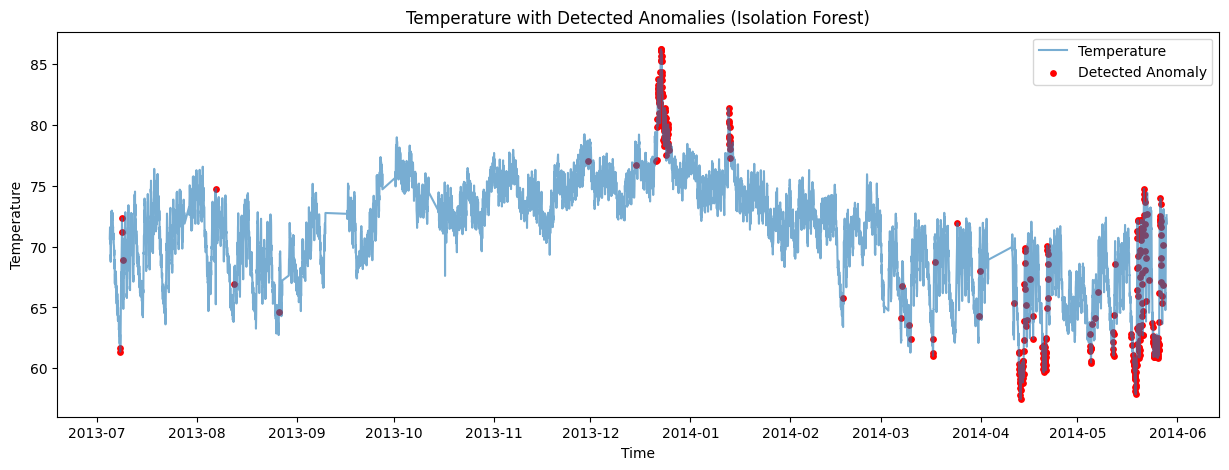

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], df['value'], label='Temperature', alpha=0.6)
plt.scatter(df[df['anomaly'] == -1]['timestamp'], df[df['anomaly'] == -1]['value'], color='red', label='Detected Anomaly', s=15)
plt.title('Temperature with Detected Anomalies (Isolation Forest)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# **Re-train with Lower Contamination and Compare**

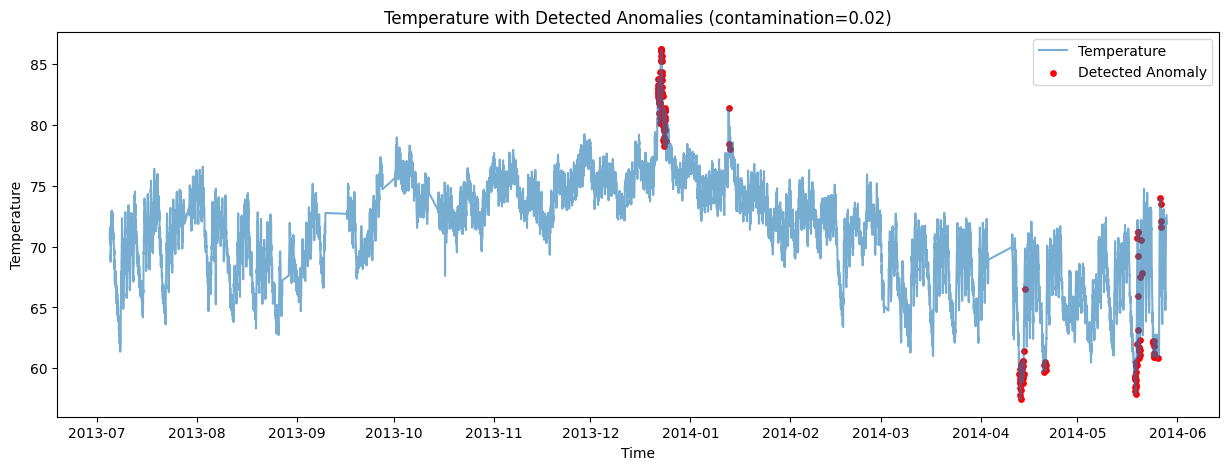

In [11]:
model_v2 = IsolationForest(contamination=0.02, random_state=42)
model_v2.fit(X)
df['anomaly_v2'] = model_v2.predict(X)

plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], df['value'], label='Temperature', alpha=0.6)
plt.scatter(df[df['anomaly_v2'] == -1]['timestamp'], df[df['anomaly_v2'] == -1]['value'], color='red', label='Detected Anomaly', s=15)
plt.title('Temperature with Detected Anomalies (contamination=0.02)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# **Finalize and Save the Model + Results**

In [12]:
df['anomaly'] = df['anomaly_v2']
df = df.drop(columns=['anomaly_v2'])

df.to_csv("anomaly_results.csv", index=False)

import joblib
joblib.dump(model_v2, "isolation_forest_model.pkl")

['isolation_forest_model.pkl']